# Project Name – Workplace Mental Health and Employee Wellbeing Analysis

# Summary:

  This project analyzes 1,259 workplace mental-health survey responses across 27 variables. Data was cleaned by standardizing gender, treating invalid ages, handling missing values, and creating analytical features. Over 20 UBM-based charts examined treatment, work interference, benefits, care options, leave and workplace stigma. Findings support clearer benefit communication, confidential care access, manager training and improved leave policies.

# Business Objective

  The business objective is to analyze workplace mental-health patterns, identify factors associated with treatment and work interference, and evaluate employees’ awareness of organizational support. The analysis aims to recommend actions that improve access to care, reduce stigma, strengthen psychological safety, and minimize productivity loss, absenteeism and employee turnover.

In [ ]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loding the dataset
df=pd.read_csv('survey.csv')

In [ ]:
#dataset first look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [7]:
#dataset rows & columns count
print(" Number of Rows:", df.shape[0])
print(" Number of Columns:", df.shape[1])

 Number of Rows: 1259
 Number of Columns: 27


In [8]:
#dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [9]:
#dataset duplicate value count
print("Number of duplicate values:", df.duplicated().sum())

Number of duplicate values: 0


In [12]:
#dataset null value count for each column
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [10]:
#dataset null value count
print("Number of null values:", df.isnull().sum().sum())

Number of null values: 1892


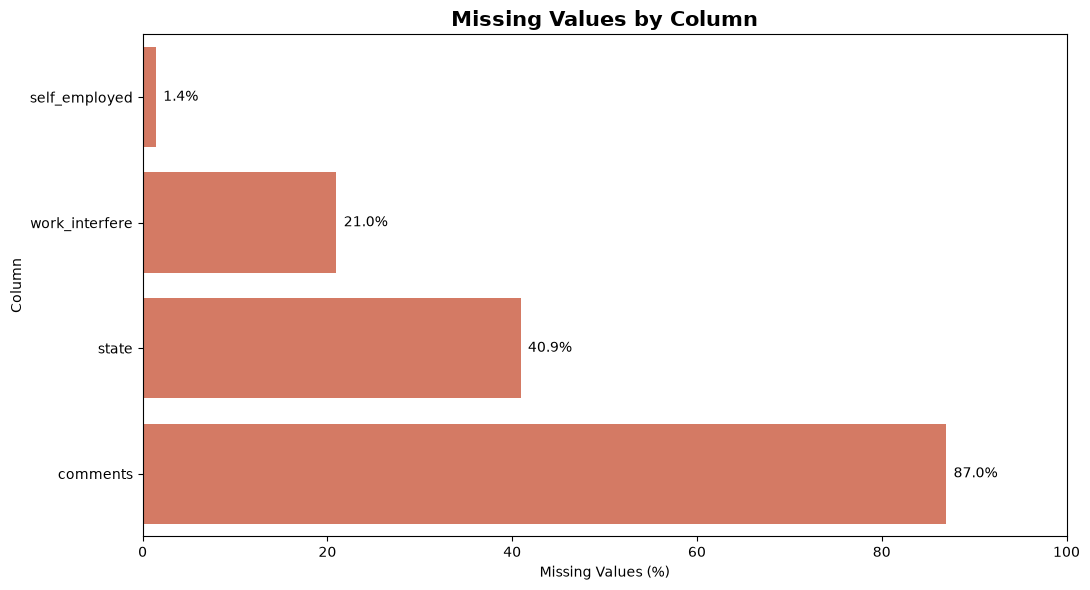

,Null Count,Null Percentage
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


In [ ]:
# Calculate missing-value count and percentage for every column.
raw_df = df.copy()
null_summary = pd.DataFrame({
    "Null Count": raw_df.isnull().sum(),
    "Null Percentage": raw_df.isnull().mean() * 100
})

# Keep only columns containing at least one null value.
null_summary = (
    null_summary[null_summary["Null Count"] > 0]
    .sort_values("Null Percentage", ascending=True)
)

# Create a horizontal bar chart for easy comparison.
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=null_summary.reset_index(),
    x="Null Percentage",
    y="index",
    color="#E76F51"
)

# Add percentage labels to each bar.
for bar in ax.patches:
    percentage = bar.get_width()

    ax.text(
        percentage + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center",
        fontsize=10
    )

# Format the chart.
plt.title("Missing Values by Column", fontsize=15, fontweight="bold")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Display the supporting null-value table.
display(
    null_summary.sort_values(
        "Null Percentage",
        ascending=False
    ).round(2)
)

In [14]:
# Clean the dataset for analysis.
df_clean = df.copy()

# State is not applicable to respondents outside the United States.
df_clean.loc[
    (df_clean["Country"] != "United States")
    & (df_clean["state"].isna()),
    "state"
] = "Not applicable"

# Missing state for US respondents remains an unknown response.
df_clean.loc[
    (df_clean["Country"] == "United States")
    & (df_clean["state"].isna()),
    "state"
] = "Not reported"

# Preserve unknown categorical responses instead of guessing Yes or No.
df_clean["self_employed"] = (
    df_clean["self_employed"].fillna("Not reported")
)

df_clean["work_interfere"] = (
    df_clean["work_interfere"].fillna("Not reported")
)

# Comments are optional and unsuitable for regular categorical analysis.
df_clean["has_comment"] = df_clean["comments"].notna().astype(int)

# Keep comments separately if text analysis is required later.
comments_df = df_clean[df_clean["comments"].notna()].copy()

# Remove comments only from the structured EDA dataset.
df_clean = df_clean.drop(columns=["comments"])

# Verify that the required analytical columns contain no null values.
print(df_clean.isnull().sum())

Timestamp                    0
Age                          0
Gender                       0
Country                      0
state                        0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
has_comment                  0
dtype: int64


In [ ]:
# The dataset contains 1,259 survey responses and 27 original variables related to mental health in the workplace. 
# It includes respondent demographics, employment characteristics, access to mental-health support, workplace attitudes, 
# perceived consequences of disclosure, and treatment history.

# The important observations are:

# treatment is the main outcome variable and indicates whether a respondent has sought mental-health treatment.
# Most variables are categorical, such as benefits, remote_work, family_history, work_interfere, and supervisor.
# Age is numerical, while Timestamp is a date-time variable.
# The dataset contains inconsistent free-text gender values that require standardization.
# Some age values are unrealistic, including negative values and extremely large numbers.
# Missing values are present in:
# state: 515
# self_employed: 18
# work_interfere: 264
# comments: 1,095
# Missing state values may be valid for respondents outside the United States.
# comments is an optional free-text field and is unsuitable for normal categorical analysis because approximately 87% of its values are missing.
# The dataset is dominated by respondents from the United States and by male respondents, so results should not be generalized to every country or gender group without caution.
# The data is observational and self-reported. Therefore, relationships found during analysis represent associations and should not be interpreted as causal relationships.

In [16]:
# Display all variable or column names available in the dataset.
print("Dataset Variables:")
for column_number, column_name in enumerate(df.columns, start=1):
    print(f"{column_number}. {column_name}")

Dataset Variables:
1. Timestamp
2. Age
3. Gender
4. Country
5. state
6. self_employed
7. family_history
8. treatment
9. work_interfere
10. no_employees
11. remote_work
12. tech_company
13. benefits
14. care_options
15. wellness_program
16. seek_help
17. anonymity
18. leave
19. mental_health_consequence
20. phys_health_consequence
21. coworkers
22. supervisor
23. mental_health_interview
24. phys_health_interview
25. mental_vs_physical
26. obs_consequence
27. comments


In [ ]:
# variable description
variables_description = pd.DataFrame({
    "Variable": [
        "Timestamp",
        "Age",
        "Gender",
        "Country",
        "state",
        "self_employed",
        "family_history",
        "treatment",
        "work_interfere",
        "no_employees",
        "remote_work",
        "tech_company",
        "benefits",
        "care_options",
        "wellness_program",
        "seek_help",
        "anonymity",
        "leave",
        "mental_health_consequence",
        "phys_health_consequence",
        "coworkers",
        "supervisor",
        "mental_health_interview",
        "phys_health_interview",
        "mental_vs_physical",
        "obs_consequence",
        "comments"
    ],

    "Variable Type": [
        "Date-time",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Binary categorical",
        "Binary categorical",
        "Binary categorical",
        "Ordinal categorical",
        "Ordinal categorical",
        "Binary categorical",
        "Binary categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Ordinal categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Binary categorical",
        "Free-text"
    ],

    "Description": [
            "Date and time when the respondent completed the survey",
            "Age of the respondent",
            "Self-reported gender of the respondent",
            "Country where the respondent lives or works",
            "US state of the respondent",
            "Whether the respondent is self-employed",
            "Whether the respondent has a family history of mental illness",
            "Whether the respondent has sought mental-health treatment",
            "Frequency with which mental health interferes with work",
            "Organization size based on number of employees",
            "Whether the respondent works remotely at least 50% of the time",
            "Whether the employer is primarily a technology company",
            "Whether the employer provides mental-health benefits",
            "Awareness of available mental-health care options",
            "Whether mental health is included in the employer wellness program",
            "Whether the employer provides resources for seeking help",
            "Whether employee anonymity is protected",
            "Perceived ease of taking mental-health leave",
            "Expected consequences of discussing a mental-health condition",
            "Expected consequences of discussing a physical-health condition",
            "Willingness to discuss mental health with coworkers",
            "Willingness to discuss mental health with a supervisor",
            "Willingness to discuss mental health during a job interview",
            "Willingness to discuss physical health during a job interview",
            "Whether mental health is treated as seriously as physical health",
            "Whether negative consequences for coworkers have been observed",
            "Optional comments provided by the respondent"
        ]
})

# Display the complete variables-description table.
pd.set_option("display.max_colwidth", None)
display(variables_description)

,Variable,Variable Type,Description
0,Timestamp,Date-time,Date and time when the respondent completed the survey
1,Age,Numerical,Age of the respondent
2,Gender,Categorical,Self-reported gender of the respondent
3,Country,Categorical,Country where the respondent lives or works
4,state,Categorical,US state of the respondent
5,self_employed,Binary categorical,Whether the respondent is self-employed
6,family_history,Binary categorical,Whether the respondent has a family history of mental illness
7,treatment,Binary categorical,Whether the respondent has sought mental-health treatment
8,work_interfere,Ordinal categorical,Frequency with which mental health interferes with work
9,no_employees,Ordinal categorical,Organization size based on number of employees


In [27]:
# Check the number of unique values and their categories for each variable.
# High-cardinality columns are summarized to prevent excessively large output.

def check_unique_values(dataframe, display_limit=20):
    """
    Display unique-value information for every column.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to be analysed.
    display_limit : int
        Maximum number of unique values displayed for a column.
    """

    for column in dataframe.columns:

        # Count unique values, including missing values.
        unique_count = dataframe[column].nunique(dropna=False)

        print("=" * 80)
        print(f"Variable: {column}")
        print(f"Unique values: {unique_count}")

        # Display all categories for low-cardinality variables.
        if unique_count <= display_limit:
            print(
                dataframe[column]
                .value_counts(dropna=False)
                .to_string()
            )

        # Display only a sample for high-cardinality variables.
        else:
            sample_values = (
                dataframe[column]
                .drop_duplicates()
                .head(display_limit)
                .tolist()
            )

            print(f"First {display_limit} unique values:")
            print(sample_values)
            print("Remaining values are not displayed because the variable has high cardinality.")

        print()


# Execute the unique-value analysis.
check_unique_values(df, display_limit=20)

Variable: Timestamp
Unique values: 1246
First 20 unique values:
['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44', '2014-08-27 11:29:46', '2014-08-27 11:30:22', '2014-08-27 11:31:22', '2014-08-27 11:31:50', '2014-08-27 11:32:05', '2014-08-27 11:32:39', '2014-08-27 11:32:43', '2014-08-27 11:32:44', '2014-08-27 11:32:49', '2014-08-27 11:33:23', '2014-08-27 11:33:26', '2014-08-27 11:33:57', '2014-08-27 11:34:00', '2014-08-27 11:34:20', '2014-08-27 11:34:37', '2014-08-27 11:34:53', '2014-08-27 11:35:08']
Remaining values are not displayed because the variable has high cardinality.

Variable: Age
Unique values: 53
First 20 unique values:
[37, 44, 32, 31, 33, 35, 39, 42, 23, 29, 36, 27, 46, 41, 34, 30, 40, 38, 50, 24]
Remaining values are not displayed because the variable has high cardinality.

Variable: Gender
Unique values: 49
First 20 unique values:
['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile', 'Trans-female', 'Cis Female', 'F', 'something kinda m

In [28]:
# ============================================================
# DATA CLEANING AND PREPARATION
# ============================================================

import pandas as pd
import numpy as np


def prepare_survey_data(dataframe):
    """
    Clean and prepare the workplace mental-health survey dataset.

    The function:
    - Preserves the original dataset
    - Removes exact duplicate records
    - Standardizes text values
    - Converts Timestamp to datetime
    - Handles invalid ages
    - Standardizes Gender
    - Handles missing values
    - Creates useful analytical variables
    - Validates the final dataset
    """

    try:
        # ----------------------------------------------------
        # 1. Validate the input
        # ----------------------------------------------------

        if not isinstance(dataframe, pd.DataFrame):
            raise TypeError("The supplied object must be a Pandas DataFrame.")

        if dataframe.empty:
            raise ValueError("The supplied dataset is empty.")

        # Preserve the original dataset.
        cleaned_df = dataframe.copy(deep=True)

        original_rows = len(cleaned_df)

        # ----------------------------------------------------
        # 2. Clean column names
        # ----------------------------------------------------

        # Remove accidental spaces from column names.
        cleaned_df.columns = cleaned_df.columns.str.strip()

        # Check for duplicated column names.
        if cleaned_df.columns.duplicated().any():
            duplicate_columns = cleaned_df.columns[
                cleaned_df.columns.duplicated()
            ].tolist()

            raise ValueError(
                f"Duplicate column names detected: {duplicate_columns}"
            )

        # ----------------------------------------------------
        # 3. Remove exact duplicate rows
        # ----------------------------------------------------

        duplicate_count = cleaned_df.duplicated().sum()

        cleaned_df = (
            cleaned_df
            .drop_duplicates()
            .reset_index(drop=True)
        )

        # ----------------------------------------------------
        # 4. Clean text columns
        # ----------------------------------------------------

        categorical_columns = cleaned_df.select_dtypes(
            include=["object", "string"]
        ).columns

        for column in categorical_columns:

            # Remove leading and trailing spaces.
            cleaned_df[column] = cleaned_df[column].apply(
                lambda value: value.strip()
                if isinstance(value, str)
                else value
            )

            # Convert empty strings into proper missing values.
            cleaned_df[column] = cleaned_df[column].replace(
                r"^\s*$",
                np.nan,
                regex=True
            )

        # ----------------------------------------------------
        # 5. Convert Timestamp into datetime
        # ----------------------------------------------------

        cleaned_df["Timestamp"] = pd.to_datetime(
            cleaned_df["Timestamp"],
            errors="coerce"
        )

        # Create useful date variables for possible time analysis.
        cleaned_df["Survey_Date"] = cleaned_df["Timestamp"].dt.date
        cleaned_df["Survey_Year"] = cleaned_df["Timestamp"].dt.year
        cleaned_df["Survey_Month"] = cleaned_df["Timestamp"].dt.month_name()

        # ----------------------------------------------------
        # 6. Clean the Age variable
        # ----------------------------------------------------

        # Convert age into a numeric variable.
        cleaned_df["Age"] = pd.to_numeric(
            cleaned_df["Age"],
            errors="coerce"
        )

        # Ages outside 18–80 are considered invalid.
        invalid_age_mask = ~cleaned_df["Age"].between(18, 80)

        invalid_age_count = invalid_age_mask.sum()

        # Preserve all respondents but exclude invalid ages from age analysis.
        cleaned_df.loc[invalid_age_mask, "Age"] = np.nan

        # Create age groups without inventing replacement ages.
        cleaned_df["Age_Group"] = pd.cut(
            cleaned_df["Age"],
            bins=[17, 24, 34, 44, 54, 64, 80],
            labels=[
                "18–24",
                "25–34",
                "35–44",
                "45–54",
                "55–64",
                "65–80"
            ]
        )

        # ----------------------------------------------------
        # 7. Standardize Gender
        # ----------------------------------------------------

        def standardize_gender(value):
            """Convert inconsistent gender responses into reporting groups."""

            if pd.isna(value):
                return "Not reported"

            gender = str(value).strip().lower()

            # Values that do not provide a valid gender response.
            invalid_values = {
                "a little about you",
                "p"
            }

            if gender in invalid_values:
                return "Not reported"

            # Explicit non-binary, transgender and gender-diverse responses.
            other_markers = [
                "trans",
                "non-binary",
                "nonbinary",
                "queer",
                "genderqueer",
                "agender",
                "androgyne",
                "enby",
                "fluid",
                "neuter",
                "unsure",
                "all",
                "nah"
            ]

            if any(marker in gender for marker in other_markers):
                return "Other / Non-binary"

            # Standardize female responses and spelling variations.
            female_values = {
                "f",
                "female",
                "woman",
                "femake",
                "femail",
                "cis female",
                "female (cis)",
                "cis-female/femme"
            }

            if (
                gender in female_values
                or "female" in gender
                or "woman" in gender
            ):
                return "Female"

            # Standardize male responses and spelling variations.
            male_values = {
                "m",
                "male",
                "man",
                "make",
                "mal",
                "maile",
                "msle",
                "mail",
                "malr",
                "cis male",
                "male (cis)",
                "cis man",
                "male-ish",
                "guy (-ish) ^_^",
                "something kinda male?",
                "male leaning androgynous"
            }

            if gender in male_values or "male" in gender:
                return "Male"

            # Retain unrecognized identity responses without guessing.
            return "Other / Non-binary"

        cleaned_df["Gender_Group"] = cleaned_df["Gender"].apply(
            standardize_gender
        )

        # ----------------------------------------------------
        # 8. Handle missing State values
        # ----------------------------------------------------

        # State is not applicable to respondents outside the US.
        non_us_missing_state = (
            cleaned_df["Country"].ne("United States")
            & cleaned_df["state"].isna()
        )

        cleaned_df.loc[
            non_us_missing_state,
            "state"
        ] = "Not applicable"

        # Missing state among US respondents is an unknown response.
        us_missing_state = (
            cleaned_df["Country"].eq("United States")
            & cleaned_df["state"].isna()
        )

        cleaned_df.loc[
            us_missing_state,
            "state"
        ] = "Not reported"

        # ----------------------------------------------------
        # 9. Handle other missing categorical values
        # ----------------------------------------------------

        # Do not assume Yes or No when a response is unavailable.
        cleaned_df["self_employed"] = (
            cleaned_df["self_employed"]
            .fillna("Not reported")
        )

        cleaned_df["work_interfere"] = (
            cleaned_df["work_interfere"]
            .fillna("Not reported")
        )

        # ----------------------------------------------------
        # 10. Handle optional Comments
        # ----------------------------------------------------

        # Create an indicator showing whether a comment was submitted.
        cleaned_df["Has_Comment"] = (
            cleaned_df["comments"]
            .notna()
            .astype(int)
        )

        # Keep non-null comments separately for optional text analysis.
        comments_df = cleaned_df.loc[
            cleaned_df["comments"].notna(),
            ["comments"]
        ].copy()

        # Remove the text column from structured EDA because most values
        # are missing and every comment may be unique.
        cleaned_df = cleaned_df.drop(columns=["comments"])

        # ----------------------------------------------------
        # 11. Create analysis-ready variables
        # ----------------------------------------------------

        # Validate the treatment categories before creating the flag.
        valid_treatment_values = {"Yes", "No"}

        unexpected_values = set(
            cleaned_df["treatment"].dropna().unique()
        ) - valid_treatment_values

        if unexpected_values:
            raise ValueError(
                f"Unexpected treatment values found: {unexpected_values}"
            )

        # Create a numerical treatment indicator for rate calculations.
        cleaned_df["Treatment_Flag"] = (
            cleaned_df["treatment"]
            .map({"Yes": 1, "No": 0})
            .astype("int8")
        )

        # Create a workplace-support score.
        support_columns = [
            "benefits",
            "care_options",
            "wellness_program",
            "seek_help",
            "anonymity"
        ]

        cleaned_df["Support_Score"] = sum(
            cleaned_df[column].eq("Yes").astype(int)
            for column in support_columns
        )

        # ----------------------------------------------------
        # 12. Set the correct category order
        # ----------------------------------------------------

        cleaned_df["work_interfere"] = pd.Categorical(
            cleaned_df["work_interfere"],
            categories=[
                "Never",
                "Rarely",
                "Sometimes",
                "Often",
                "Not reported"
            ],
            ordered=True
        )

        cleaned_df["no_employees"] = pd.Categorical(
            cleaned_df["no_employees"],
            categories=[
                "1-5",
                "6-25",
                "26-100",
                "100-500",
                "500-1000",
                "More than 1000"
            ],
            ordered=True
        )

        cleaned_df["leave"] = pd.Categorical(
            cleaned_df["leave"],
            categories=[
                "Very easy",
                "Somewhat easy",
                "Don't know",
                "Somewhat difficult",
                "Very difficult"
            ],
            ordered=True
        )

        # ----------------------------------------------------
        # 13. Final validation
        # ----------------------------------------------------

        if cleaned_df.empty:
            raise ValueError(
                "No records remain after data preparation."
            )

        if not cleaned_df["Treatment_Flag"].isin([0, 1]).all():
            raise ValueError(
                "Treatment_Flag contains invalid values."
            )

        if not cleaned_df["Support_Score"].between(0, 5).all():
            raise ValueError(
                "Support_Score contains values outside 0–5."
            )

        # Display a preparation summary.
        print("Dataset preparation completed successfully.")
        print(f"Original rows             : {original_rows}")
        print(f"Analysis-ready rows       : {len(cleaned_df)}")
        print(f"Exact duplicates removed : {duplicate_count}")
        print(f"Invalid ages identified  : {invalid_age_count}")
        print(f"Comments retained         : {len(comments_df)}")
        print(f"Final columns             : {cleaned_df.shape[1]}")

        return cleaned_df, comments_df

    except (TypeError, ValueError, KeyError) as error:
        print(f"Dataset preparation failed: {error}")
        raise


# Run the complete data-preparation process.
df_clean, comments_df = prepare_survey_data(df)

# Preview the analysis-ready dataset.
display(df_clean.head())

# Check remaining missing values.
print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Dataset preparation completed successfully.
Original rows             : 1259
Analysis-ready rows       : 1259
Exact duplicates removed : 0
Invalid ages identified  : 8
Comments retained         : 163
Final columns             : 34


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_vs_physical,obs_consequence,Survey_Date,Survey_Year,Survey_Month,Age_Group,Gender_Group,Has_Comment,Treatment_Flag,Support_Score
0,2014-08-27 11:29:31,37.0,Female,United States,IL,Not reported,No,Yes,Often,6-25,...,Yes,No,2014-08-27,2014,August,35–44,Female,0,1,3
1,2014-08-27 11:29:37,44.0,M,United States,IN,Not reported,No,No,Rarely,More than 1000,...,Don't know,No,2014-08-27,2014,August,35–44,Male,0,0,0
2,2014-08-27 11:29:44,32.0,Male,Canada,Not applicable,Not reported,No,No,Rarely,6-25,...,No,No,2014-08-27,2014,August,25–34,Male,0,0,0
3,2014-08-27 11:29:46,31.0,Male,United Kingdom,Not applicable,Not reported,Yes,Yes,Often,26-100,...,No,Yes,2014-08-27,2014,August,25–34,Male,0,1,1
4,2014-08-27 11:30:22,31.0,Male,United States,TX,Not reported,No,No,Never,100-500,...,Don't know,No,2014-08-27,2014,August,25–34,Male,0,0,1



Remaining missing values:
Age          8
Age_Group    8
dtype: int64


# Data Manipulations Performed

1. **Created a copy of the original dataset**
   - A separate DataFrame was created to ensure that the original data remained unchanged.

2. **Cleaned the column names**
   - Leading and trailing spaces were removed from column names.
   - Duplicate column names were checked to prevent ambiguous analysis.

3. **Checked and removed duplicate records**
   - The dataset was checked for exact duplicate rows.
   - No exact duplicate records were found.

4. **Standardized text values**
   - Leading and trailing spaces were removed from categorical values.
   - Empty strings were converted into proper missing values.

5. **Converted the timestamp**
   - `Timestamp` was converted from text into a date-time variable.
   - `Survey_Date`, `Survey_Year`, and `Survey_Month` were created for possible time-based analysis.

6. **Cleaned the Age variable**
   - `Age` was converted into a numerical variable.
   - Eight unrealistic age values outside the range of 18–80 were treated as missing.
   - Invalid ages were excluded only from age-based analysis; the respondents' other valid answers were retained.
   - An `Age_Group` variable was created for demographic analysis.

7. **Standardized Gender**
   - The original `Gender` column contained 49 inconsistent responses and spelling variations.
   - These responses were consolidated into:
     - `Male`
     - `Female`
     - `Other / Non-binary`
     - `Not reported`

8. **Handled missing State values**
   - Missing state values for non-US respondents were classified as `Not applicable`.
   - Missing state values for US respondents were classified as `Not reported`.
   - State values were not imputed using the mode because that would create incorrect geographical information.

9. **Handled other missing categorical values**
   - The 18 missing `self_employed` responses were replaced with `Not reported`.
   - The 264 missing `work_interfere` responses were replaced with `Not reported`.
   - Missing values were not replaced with `Yes`, `No`, or the mode because their actual responses were unknown.

10. **Handled the Comments column**
    - `comments` contained approximately 87% missing values.
    - A new binary variable called `Has_Comment` was created.
    - Available comments were stored separately for optional text analysis.
    - The original comments column was excluded from structured EDA.

11. **Created analysis-ready variables**
    - `Treatment_Flag` was created:
      - `Yes = 1`
      - `No = 0`
    - `Support_Score` was created from five workplace-support variables:
      - Benefits
      - Care options
      - Wellness program
      - Help-seeking resources
      - Anonymity
    - The score ranges from 0 to 5.

12. **Ordered ordinal categories**
    - Logical category orders were applied to:
      - `work_interfere`
      - `no_employees`
      - `leave`
    - This ensures that charts appear in a meaningful order rather than alphabetical order.

13. **Validated the cleaned dataset**
    - Treatment values and calculated scores were validated.
    - All valid respondent records were retained.
    - The final dataset was checked to ensure it was ready for analysis.

#### Initial Insights Found

- The dataset contains 1,259 workplace mental-health survey responses.
- Approximately 50.6% of respondents reported seeking mental-health treatment.
- Around 48.4% reported that mental health interfered with work sometimes or often.
- Approximately 32.4% did not know whether their employer provided mental-health benefits.
- Around 64.7% answered `No` or `Not sure` regarding available mental-health care options.
- Approximately 44.7% did not know how easy it would be to take mental-health leave.
- Around 61.1% believed that discussing mental health could have workplace consequences or were uncertain about the consequences.
- Respondents with a family history of mental illness had a considerably higher treatment rate.
- Treatment rates increased as the reported frequency of work interference increased.
- The survey sample was dominated by respondents from the United States and by male respondents, which limits generalization.
- A low relationship between workplace support and perceived stigma suggests that providing benefits alone may not remove employees' fear of discussing mental health.

#### Business Impact

The findings can help organizations:

- Improve communication about mental-health benefits.
- Make care options easier to locate and understand.
- Establish clear mental-health leave procedures.
- Train supervisors to handle mental-health discussions appropriately.
- Strengthen confidentiality and non-retaliation policies.
- Provide early support to employees experiencing work interference.

The analysis shows associations rather than causal relationships because the dataset is observational and self-reported.

In [31]:
# Apply a consistent visual theme.
sns.set_theme(style="whitegrid")

# Set the default chart size and resolution.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


def complete_chart(title, xlabel, ylabel, rotation=0):
    """Apply consistent formatting and display the chart."""

    plt.title(title, fontsize=14, pad=12)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if rotation:
        plt.xticks(rotation=rotation, ha="right")

    plt.tight_layout()
    plt.show()
    plt.close()


def add_bar_labels(axis, decimal_places=0, suffix=""):
    """Display values on the bars."""

    for container in axis.containers:
        try:
            axis.bar_label(
                container,
                fmt=f"%.{decimal_places}f{suffix}",
                padding=3,
                fontsize=9
            )
        except (AttributeError, ValueError):
            pass


def treatment_rate_by(column):
    """Calculate treatment rate and sample size by category."""

    result = (
        df_clean.groupby(column, observed=True)["Treatment_Flag"]
        .agg(Responses="size", Treatment_Rate="mean")
        .reset_index()
    )

    result["Treatment_Rate"] *= 100

    return result

# Chart 1: Age Distribution

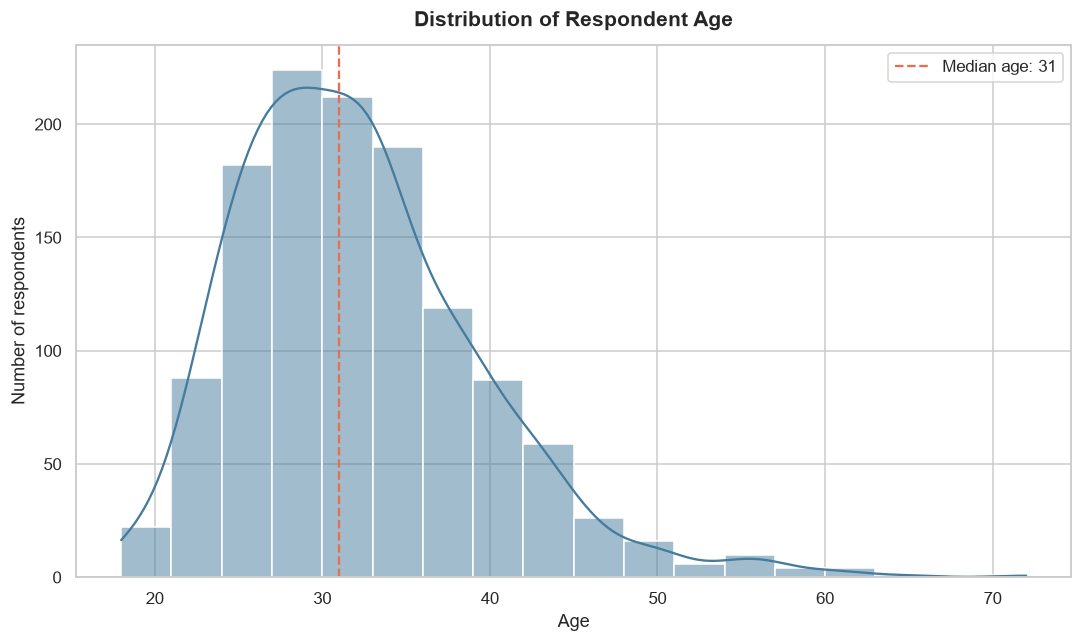

Why this graph:
A histogram was selected because Age is a continuous numerical variable.
It shows the distribution, concentration, spread and possible unusual values more clearly than a bar or pie chart.

Insight: The median respondent age is 31.
Most respondents are concentrated in the young and middle-aged working population

Positive Impact:Organizations can design mental-health communication and support programs according to the main workforce age segment.

Negative Impact: The sample may underrepresent older and younger workers.


In [41]:
# Remove the eight missing ages only from this chart.
age_data = df_clean["Age"].dropna()

# A histogram shows the distribution of a numerical variable.
ax = sns.histplot(
    age_data,
    bins=18,
    kde=True,
    color="#457B9D"
)

# Add the median as a reference line.
median_age = age_data.median()

plt.axvline(
    median_age,
    color="#E76F51",
    linestyle="--",
    label=f"Median age: {median_age:.0f}"
)

plt.legend()

complete_chart(
    "Distribution of Respondent Age",
    "Age",
    "Number of respondents"
)
print("Why this graph:\nA histogram was selected because Age is a continuous numerical variable.\nIt shows the distribution, concentration, spread and possible unusual values more clearly than a bar or pie chart.")
print(f"\nInsight: The median respondent age is {median_age:.0f}.\nMost respondents are concentrated in the young and middle-aged working population")
print("\nPositive Impact:Organizations can design mental-health communication and support programs according to the main workforce age segment.")
print("\nNegative Impact: The sample may underrepresent older and younger workers.")

# Chart 2: Respondents by Age Group

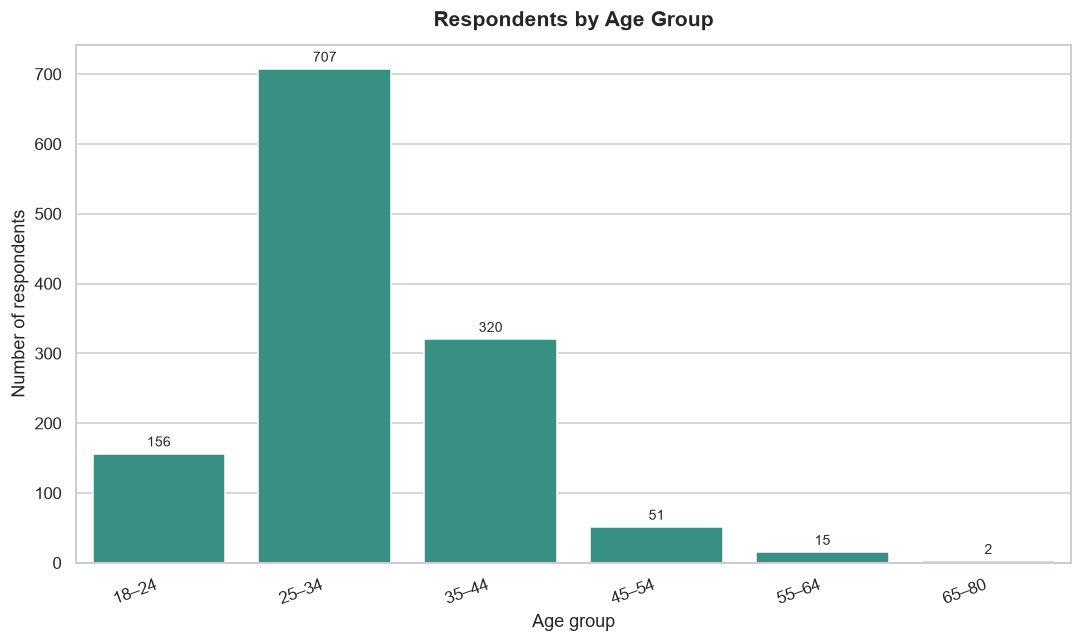

Why this graph:
A bar chart was selected because Age_Group is a categorical variable.
It provides an accurate comparison of respondent counts across age groups.

Insights: The largest respondent group is 25–34, with 707 respondents.

Positive Impact: The organization can identify its most represented employee segment and customize awareness programs accordingly.

Negative Impact: Unequal representation means that the requirements of smaller age groups may not be fully reflected.


In [40]:
# Exclude the eight missing age groups from age-group analysis.
age_group_counts = (
    df_clean["Age_Group"]
    .dropna()
    .value_counts(sort=False)
)

ax = sns.barplot(
    x=age_group_counts.index.astype(str),
    y=age_group_counts.values,
    color="#2A9D8F"
)

add_bar_labels(ax)

complete_chart(
    "Respondents by Age Group",
    "Age group",
    "Number of respondents",
    rotation=20
)

largest_age_group = age_group_counts.idxmax()

print("Why this graph:\nA bar chart was selected because Age_Group is a categorical variable.\nIt provides an accurate comparison of respondent counts across age groups.")
print(f"\nInsights: The largest respondent group is {age_group_counts.idxmax()}, with {age_group_counts.max()} respondents.")
print("\nPositive Impact: The organization can identify its most represented employee segment and customize awareness programs accordingly.")
print("\nNegative Impact: Unequal representation means that the requirements of smaller age groups may not be fully reflected.")

# Chart 3: Gender Distribution

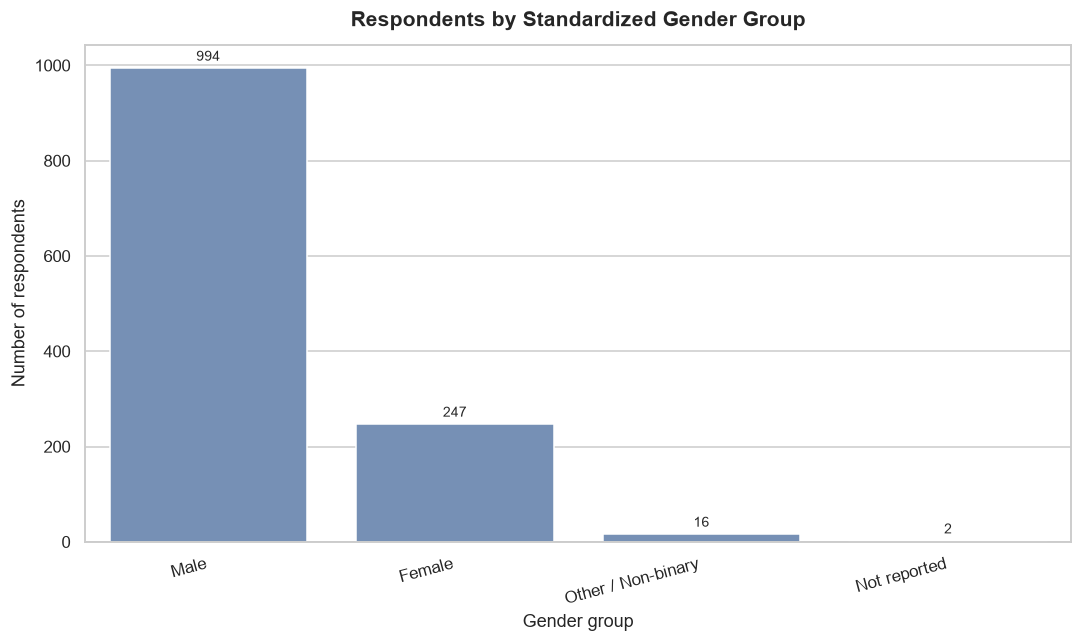

Why this graph:
A bar chart was selected because gender is categorical and the chart allows category sizes to be compared clearly.

Insights: Male is the largest gender group, representing 79.0% of respondents.

Positive Impact: Representation analysis can help improve the sampling strategy for future employee surveys.

Negative Impact: The gender imbalance may prevent the findings from representing the experiences of smaller gender groups accurately.


In [43]:
gender_counts = df_clean["Gender_Group"].value_counts()

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    color="#6C8EBF"
)

add_bar_labels(ax)

complete_chart(
    "Respondents by Standardized Gender Group",
    "Gender group",
    "Number of respondents",
    rotation=15
)

largest_gender = gender_counts.idxmax()
largest_gender_share = gender_counts.max() / len(df_clean) * 100


print("Why this graph:\nA bar chart was selected because gender is categorical and the chart allows category sizes to be compared clearly.")
print(f"\nInsights: {gender_counts.idxmax()} is the largest gender group, representing {gender_counts.max() / len(df_clean) * 100:.1f}% of respondents.")
print("\nPositive Impact: Representation analysis can help improve the sampling strategy for future employee surveys.")
print("\nNegative Impact: The gender imbalance may prevent the findings from representing the experiences of smaller gender groups accurately.")

# Chart 4: Treatment Distribution

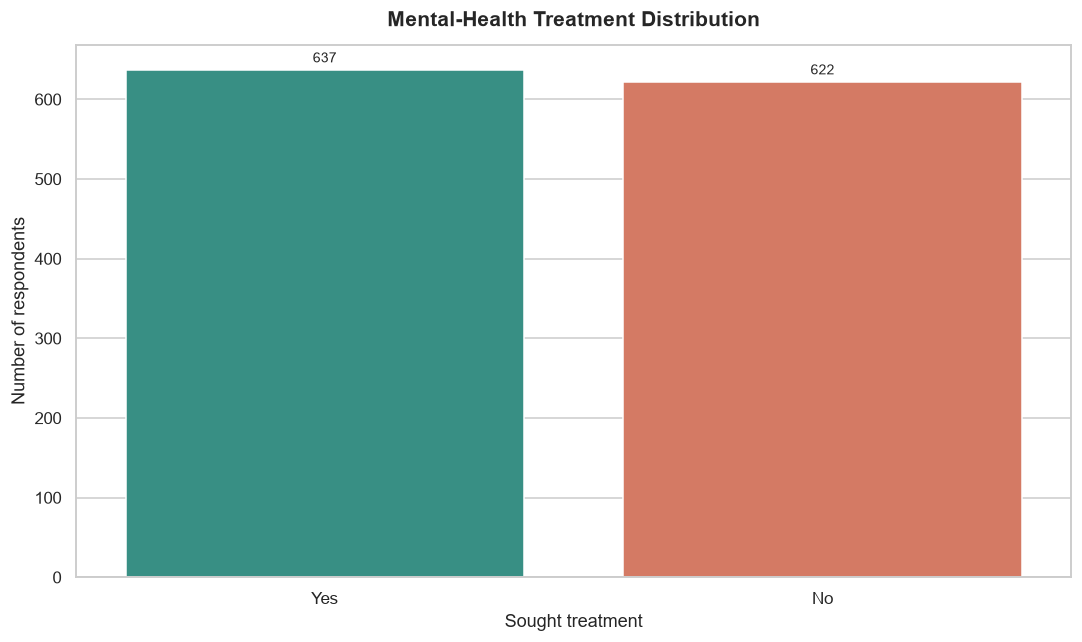

Why this graph:
A bar chart was selected because treatment is a binary categorical variable. Bars provide a more precise comparison than a pie chart.

Insights: 50.6% of respondents reported seeking mental-health treatment.

Positive Impact: The result can help organizations estimate the need for counselling, insurance coverage and employee-assistance services.

Negative Impact: A large treatment percentage may indicate a considerable mental-health burden. However, seeking treatment is a positive help-seeking action.


In [44]:
treatment_counts = (
    df_clean["treatment"]
    .value_counts()
    .reindex(["Yes", "No"])
)

ax = sns.barplot(
    x=treatment_counts.index,
    y=treatment_counts.values,
    hue=treatment_counts.index,
    palette={"Yes": "#2A9D8F", "No": "#E76F51"},
    legend=False
)

add_bar_labels(ax)

complete_chart(
    "Mental-Health Treatment Distribution",
    "Sought treatment",
    "Number of respondents"
)

treatment_percentage = df_clean["Treatment_Flag"].mean() * 100

print("Why this graph:\nA bar chart was selected because treatment is a binary categorical variable. Bars provide a more precise comparison than a pie chart.")
print(f"\nInsights: {df_clean['Treatment_Flag'].mean() * 100:.1f}% of respondents reported seeking mental-health treatment.")
print("\nPositive Impact: The result can help organizations estimate the need for counselling, insurance coverage and employee-assistance services.")
print("\nNegative Impact: A large treatment percentage may indicate a considerable mental-health burden. However, seeking treatment is a positive help-seeking action.")


#  Chart 5: Work-Interference Frequency

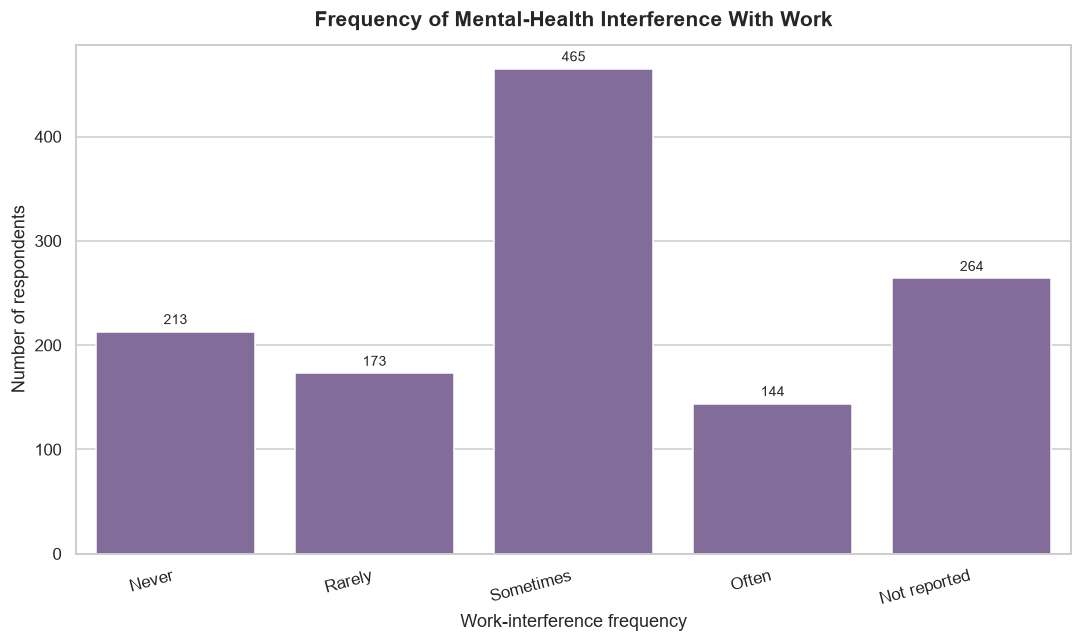

Why this graph:
An ordered bar chart was selected because work_interfere is an ordinal categorical variable ranging from Never to Often.

Insights: 48.4% of respondents reported that mental health interfered with work sometimes or often.

Positive Impact: The organization can introduce early assistance, workload support and reasonable accommodations.

Negative Impact: Frequent interference can contribute to reduced productivity, absence, burnout and employee attrition.


In [45]:
work_order = [
    "Never",
    "Rarely",
    "Sometimes",
    "Often",
    "Not reported"
]

work_counts = (
    df_clean["work_interfere"]
    .value_counts()
    .reindex(work_order, fill_value=0)
)

ax = sns.barplot(
    x=work_counts.index,
    y=work_counts.values,
    color="#8064A2"
)

add_bar_labels(ax)

complete_chart(
    "Frequency of Mental-Health Interference With Work",
    "Work-interference frequency",
    "Number of respondents",
    rotation=15
)

frequent_interference = (
    df_clean["work_interfere"]
    .isin(["Sometimes", "Often"])
    .mean() * 100
)

print("Why this graph:\nAn ordered bar chart was selected because work_interfere is an ordinal categorical variable ranging from Never to Often.")
print(f"\nInsights: {frequent_interference:.1f}% of respondents reported that mental health interfered with work sometimes or often.")
print("\nPositive Impact: The organization can introduce early assistance, workload support and reasonable accommodations.")
print("\nNegative Impact: Frequent interference can contribute to reduced productivity, absence, burnout and employee attrition.")


# Chart 6: Availability of Mental-Health Benefits

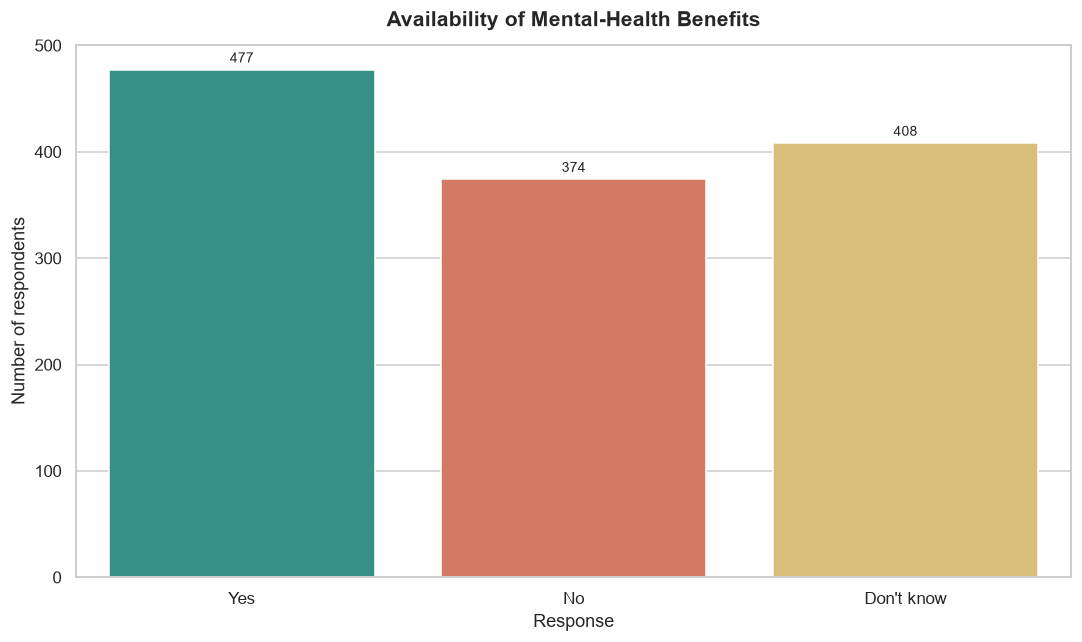

Why this graph:
A bar chart was selected to compare employees who answered Yes, No or Don't know about mental-health benefits.

Insights: 32.4% of respondents did not know whether their employer provided mental-health benefits.

Positive Impact: Clear communication about existing benefits could improve utilization without requiring major additional investment.

Negative Impact: Employees may delay care when they do not know which benefits are available.


In [46]:
benefits_order = ["Yes", "No", "Don't know"]

benefits_counts = (
    df_clean["benefits"]
    .value_counts()
    .reindex(benefits_order)
)

ax = sns.barplot(
    x=benefits_counts.index,
    y=benefits_counts.values,
    hue=benefits_counts.index,
    palette={
        "Yes": "#2A9D8F",
        "No": "#E76F51",
        "Don't know": "#E9C46A"
    },
    legend=False
)

add_bar_labels(ax)

complete_chart(
    "Availability of Mental-Health Benefits",
    "Response",
    "Number of respondents"
)

unknown_benefits = df_clean["benefits"].eq("Don't know").mean() * 100

print("Why this graph:\nA bar chart was selected to compare employees who answered Yes, No or Don't know about mental-health benefits.")
print(f"\nInsights: {unknown_benefits:.1f}% of respondents did not know whether their employer provided mental-health benefits.")
print("\nPositive Impact: Clear communication about existing benefits could improve utilization without requiring major additional investment.")
print("\nNegative Impact: Employees may delay care when they do not know which benefits are available.")

# Chart 7: Awareness of Mental-Health Care Options

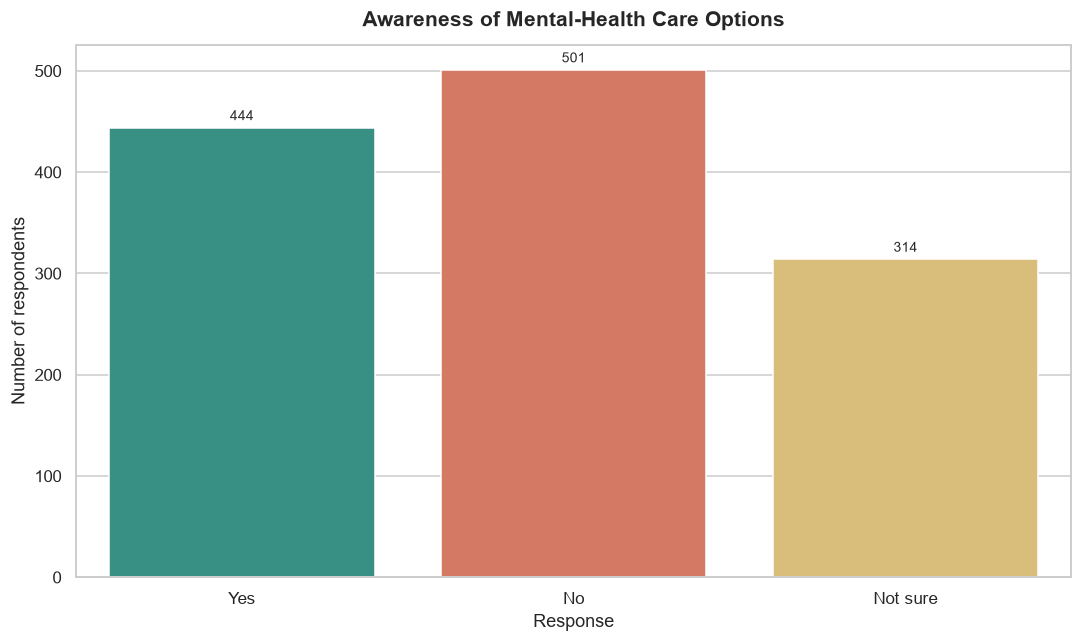

Why this graph:
A bar chart was selected because care-option awareness contains three distinct categories that need direct comparison.

Insights: 64.7% of respondents answered No or Not sure regarding available mental-health care options.

Positive Impact: A centralized care directory could make support easier to locate and use.

Negative Impact: Poor awareness can cause employees to delay treatment and reduce the value of existing support programs.


In [49]:
care_order = ["Yes", "No", "Not sure"]

care_counts = (
    df_clean["care_options"]
    .value_counts()
    .reindex(care_order)
)

ax = sns.barplot(
    x=care_counts.index,
    y=care_counts.values,
    hue=care_counts.index,
    palette={
        "Yes": "#2A9D8F",
        "No": "#E76F51",
        "Not sure": "#E9C46A"
    },
    legend=False
)

add_bar_labels(ax)

complete_chart(
    "Awareness of Mental-Health Care Options",
    "Response",
    "Number of respondents"
)

care_gap = (
    df_clean["care_options"]
    .isin(["No", "Not sure"])
    .mean() * 100
)

print("Why this graph:\nA bar chart was selected because care-option awareness contains three distinct categories that need direct comparison.")
print(f"\nInsights: {care_gap:.1f}% of respondents answered No or Not sure regarding available mental-health care options.")
print("\nPositive Impact: A centralized care directory could make support easier to locate and use.")
print("\nNegative Impact: Poor awareness can cause employees to delay treatment and reduce the value of existing support programs.")

# Chart 8: Ease of Taking Mental-Health Leave

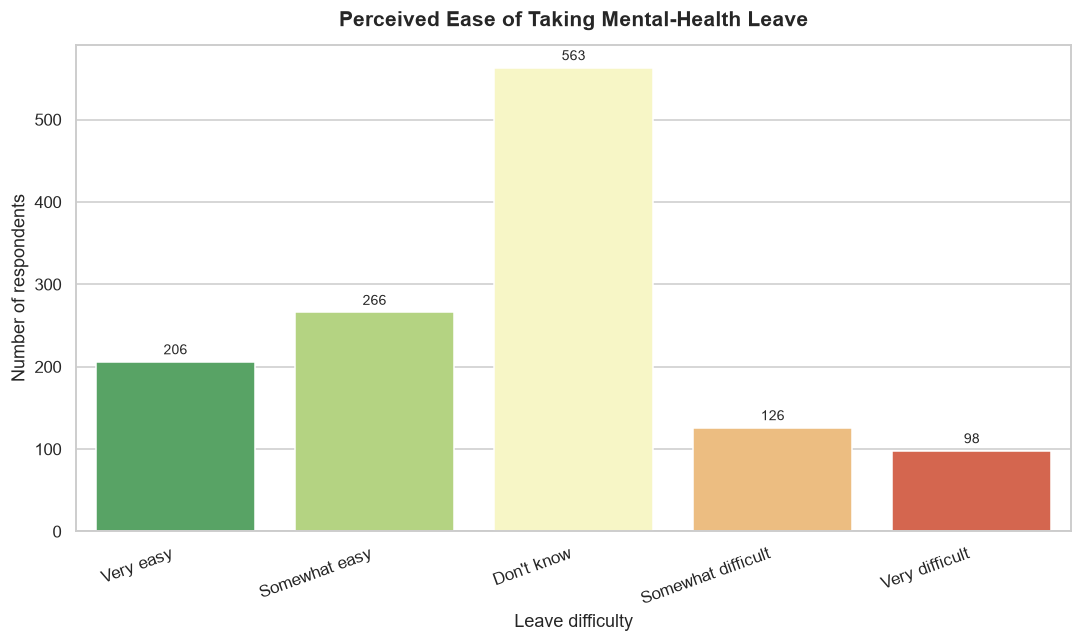

Why this graph:
An ordered bar chart was selected because leave responses represent progressive levels from Very easy to Very difficult.

Insights: 62.5% of respondents were uncertain about mental-health leave or expected difficulty taking it.

Positive Impact: Clear and consistent leave procedures can improve employee confidence and encourage timely treatment.

Negative Impact: Uncertainty or difficulty can lead to presenteeism, delayed care and longer periods of absence.


In [50]:
leave_order = [
    "Very easy",
    "Somewhat easy",
    "Don't know",
    "Somewhat difficult",
    "Very difficult"
]

leave_counts = (
    df_clean["leave"]
    .value_counts()
    .reindex(leave_order)
)

ax = sns.barplot(
    x=leave_counts.index,
    y=leave_counts.values,
    hue=leave_counts.index,
    palette="RdYlGn_r",
    legend=False
)

add_bar_labels(ax)

complete_chart(
    "Perceived Ease of Taking Mental-Health Leave",
    "Leave difficulty",
    "Number of respondents",
    rotation=20
)

leave_risk = (
    df_clean["leave"]
    .isin([
        "Don't know",
        "Somewhat difficult",
        "Very difficult"
    ])
    .mean() * 100
)

print("Why this graph:\nAn ordered bar chart was selected because leave responses represent progressive levels from Very easy to Very difficult.")
print(f"\nInsights: {leave_risk:.1f}% of respondents were uncertain about mental-health leave or expected difficulty taking it.")
print("\nPositive Impact: Clear and consistent leave procedures can improve employee confidence and encourage timely treatment.")
print("\nNegative Impact: Uncertainty or difficulty can lead to presenteeism, delayed care and longer periods of absence.")


# Chart 9: Age by Treatment Status

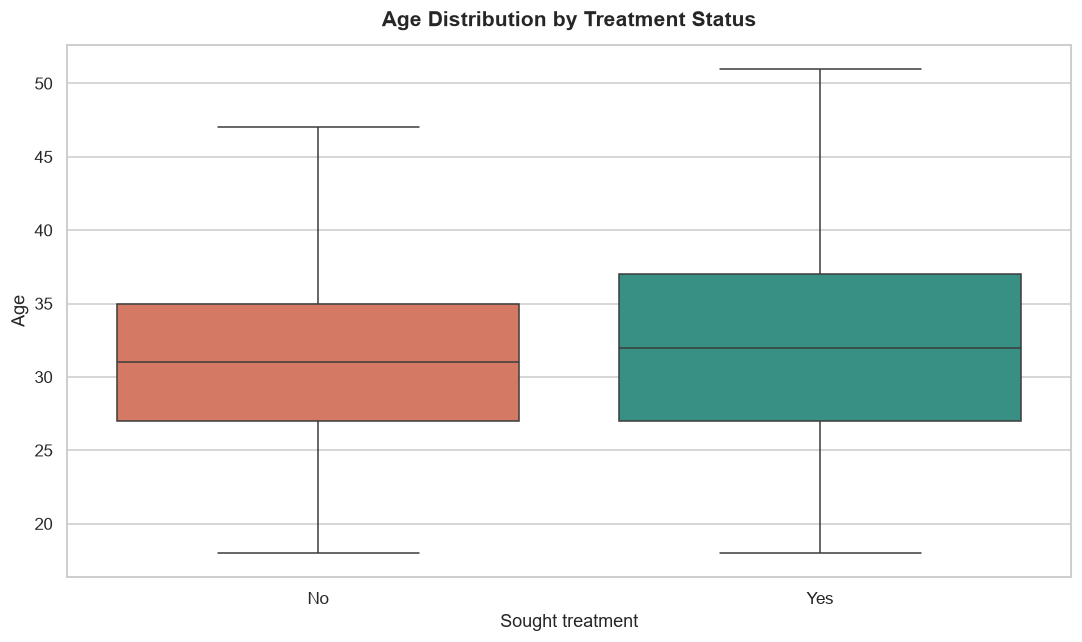

Why this graph:
A box plot was selected because it compares the distribution, median and spread of a numerical variable across treatment categories.

Insights: The median age is 32 for respondents who sought treatment and 31 for those who did not.

Positive Impact: Age-sensitive communication strategies can be tested while keeping mental-health support available to everyone.

Negative Impact: The age distributions overlap considerably, so age alone should not be used to predict treatment requirements.


In [51]:
# Exclude missing ages only from this age-related chart.
age_treatment_data = df_clean.dropna(
    subset=["Age", "treatment"]
)

ax = sns.boxplot(
    data=age_treatment_data,
    x="treatment",
    y="Age",
    order=["No", "Yes"],
    hue="treatment",
    palette={"Yes": "#2A9D8F", "No": "#E76F51"},
    legend=False,
    showfliers=False
)

complete_chart(
    "Age Distribution by Treatment Status",
    "Sought treatment",
    "Age"
)

median_ages = (
    age_treatment_data
    .groupby("treatment")["Age"]
    .median()
)


print("Why this graph:\nA box plot was selected because it compares the distribution, median and spread of a numerical variable across treatment categories.")
print(f"\nInsights: The median age is {median_ages['Yes']:.0f} for respondents who sought treatment and {median_ages['No']:.0f} for those who did not.")
print("\nPositive Impact: Age-sensitive communication strategies can be tested while keeping mental-health support available to everyone.")
print("\nNegative Impact: The age distributions overlap considerably, so age alone should not be used to predict treatment requirements.")


# Chart 10: Treatment Rate by Gender

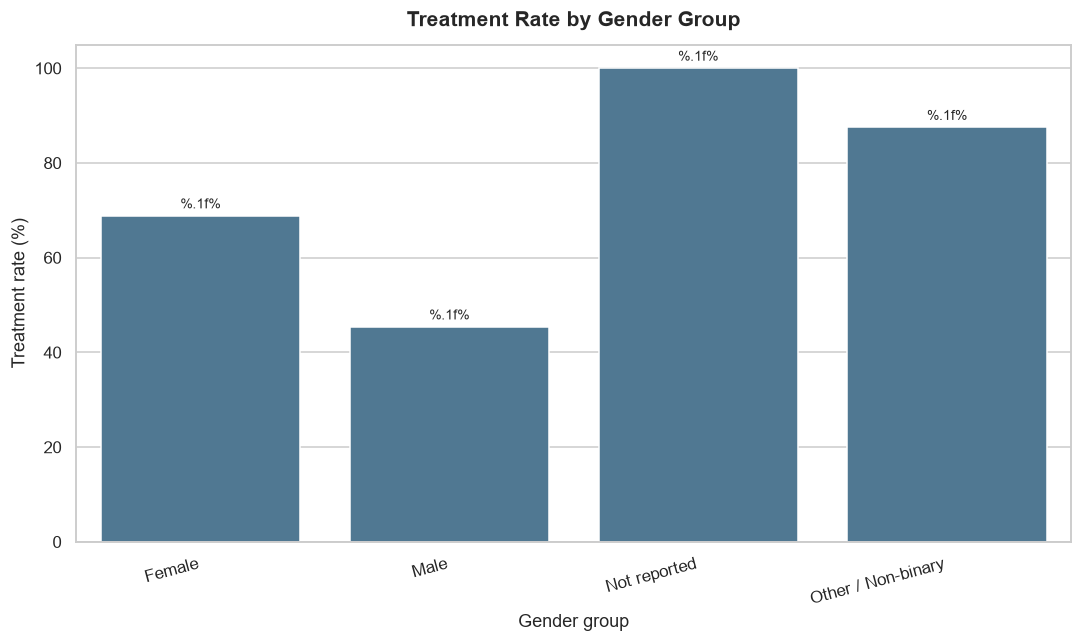

Why this graph:
A percentage bar chart was selected because gender groups have different sample sizes. Rates allow a fairer comparison than counts.

Insights: Not reported has the highest observed treatment rate at 100.0%.

Positive Impact: Differences can guide inclusive communication and confidential access to support.

Negative Impact: Some gender groups have small sample sizes, which can produce unstable percentages. Gender must not be used for individual risk prediction.


In [52]:
gender_treatment = treatment_rate_by("Gender_Group")

ax = sns.barplot(
    data=gender_treatment,
    x="Gender_Group",
    y="Treatment_Rate",
    color="#457B9D"
)

add_bar_labels(ax, decimal_places=1, suffix="%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Gender Group",
    "Gender group",
    "Treatment rate (%)",
    rotation=15
)

highest_group = gender_treatment.loc[
    gender_treatment["Treatment_Rate"].idxmax()
]

print("Why this graph:\nA percentage bar chart was selected because gender groups have different sample sizes. Rates allow a fairer comparison than counts.")
print(f"\nInsights: {highest_group['Gender_Group']} has the highest observed treatment rate at {highest_group['Treatment_Rate']:.1f}%.")
print("\nPositive Impact: Differences can guide inclusive communication and confidential access to support.")
print("\nNegative Impact: Some gender groups have small sample sizes, which can produce unstable percentages. Gender must not be used for individual risk prediction.")


# Chart 11: Family History and Treatment

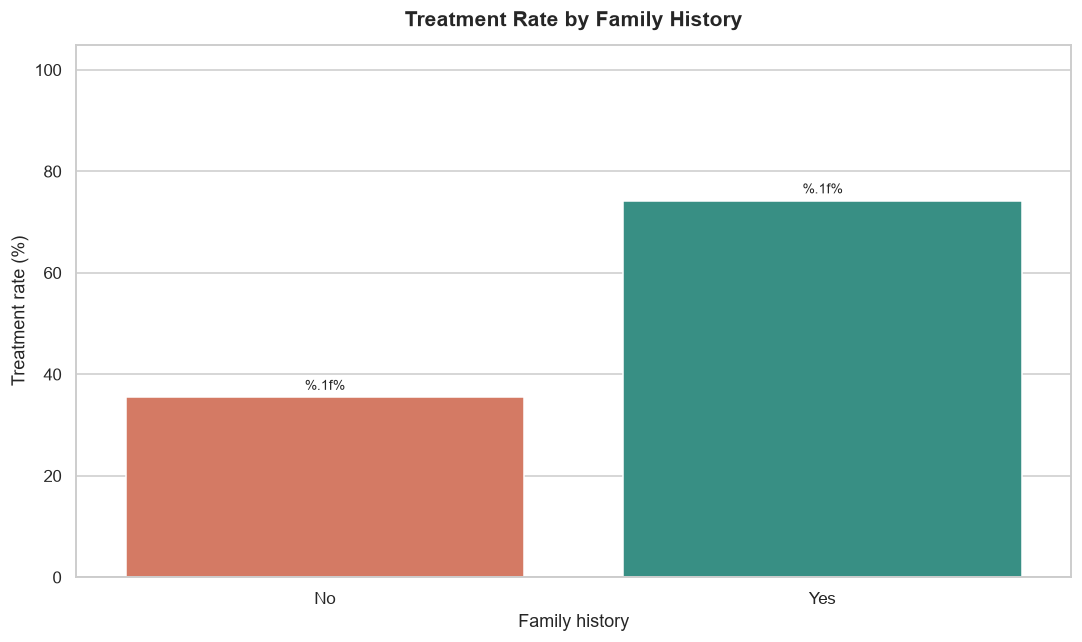

Why this graph:
A percentage bar chart was selected to examine the relationship between two binary categorical variables.

Insights: Respondents with a family history have a treatment rate that is 38.7 percentage points higher.

Positive Impact: Privacy-safe awareness programs may encourage earlier help-seeking.

Negative Impact: amily history is sensitive information and must never be used for recruitment, promotion or performance decisions.


In [53]:
family_treatment = treatment_rate_by("family_history")

ax = sns.barplot(
    data=family_treatment,
    x="family_history",
    y="Treatment_Rate",
    hue="family_history",
    palette={"Yes": "#2A9D8F", "No": "#E76F51"},
    legend=False
)

add_bar_labels(ax, decimal_places=1, suffix="%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Family History",
    "Family history",
    "Treatment rate (%)"
)

family_rates = family_treatment.set_index(
    "family_history"
)["Treatment_Rate"]

family_gap = family_rates["Yes"] - family_rates["No"]


print("Why this graph:\nA percentage bar chart was selected to examine the relationship between two binary categorical variables.")
print(f"\nInsights: Respondents with a family history have a treatment rate that is {family_gap:.1f} percentage points higher.")
print("\nPositive Impact: Privacy-safe awareness programs may encourage earlier help-seeking.")
print("\nNegative Impact: amily history is sensitive information and must never be used for recruitment, promotion or performance decisions.")

# Chart 12: Work Interference and Treatment

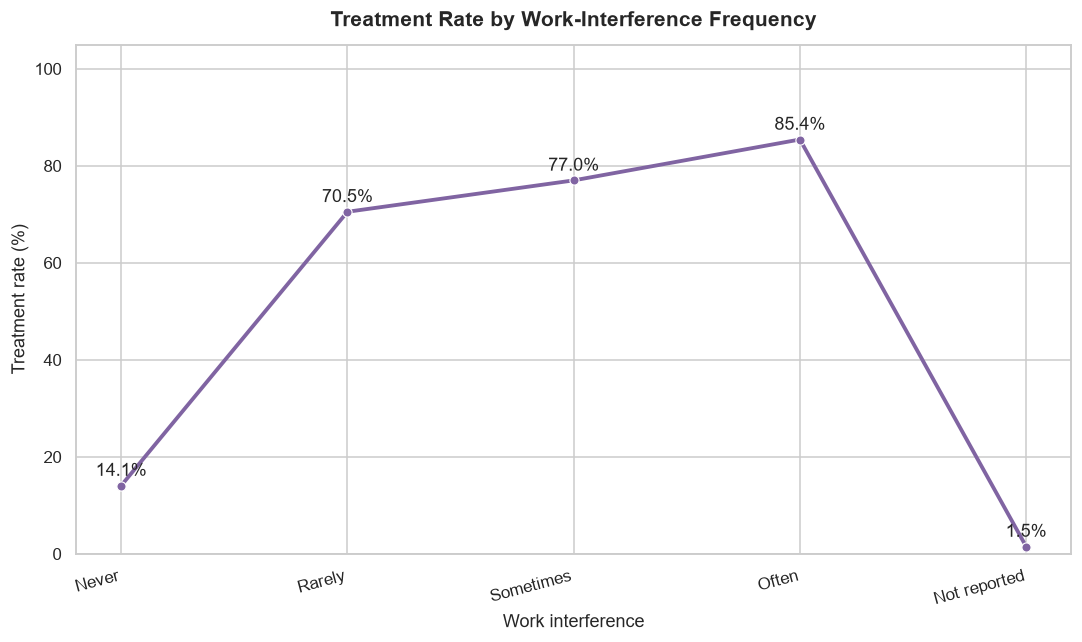

Why this graph:
An ordered line chart was selected to show how the treatment rate changes as the frequency of work interference increases.

Insights: The treatment rate is 71.3 percentage points higher among respondents reporting Often compared with Never.

Positive Impact: The pattern can help organizations provide support before work interference becomes severe.

Negative Impact: Increasing interference may negatively affect employee productivity, attendance and retention.


In [54]:
work_treatment = treatment_rate_by("work_interfere")

# Preserve the logical frequency order.
work_treatment["work_interfere"] = pd.Categorical(
    work_treatment["work_interfere"],
    categories=work_order,
    ordered=True
)

work_treatment = work_treatment.sort_values("work_interfere")

ax = sns.lineplot(
    data=work_treatment,
    x="work_interfere",
    y="Treatment_Rate",
    marker="o",
    linewidth=2.5,
    color="#8064A2"
)

for position, value in enumerate(work_treatment["Treatment_Rate"]):
    plt.text(position, value + 2, f"{value:.1f}%", ha="center")

plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Work-Interference Frequency",
    "Work interference",
    "Treatment rate (%)",
    rotation=15
)

work_rates = work_treatment.set_index(
    "work_interfere"
)["Treatment_Rate"]

difference = work_rates["Often"] - work_rates["Never"]



print("Why this graph:\nAn ordered line chart was selected to show how the treatment rate changes as the frequency of work interference increases.")
print(f"\nInsights: The treatment rate is {difference:.1f} percentage points higher among respondents reporting Often compared with Never.")
print("\nPositive Impact: The pattern can help organizations provide support before work interference becomes severe.")
print("\nNegative Impact: Increasing interference may negatively affect employee productivity, attendance and retention.")

# Chart 13: Benefits and Treatment

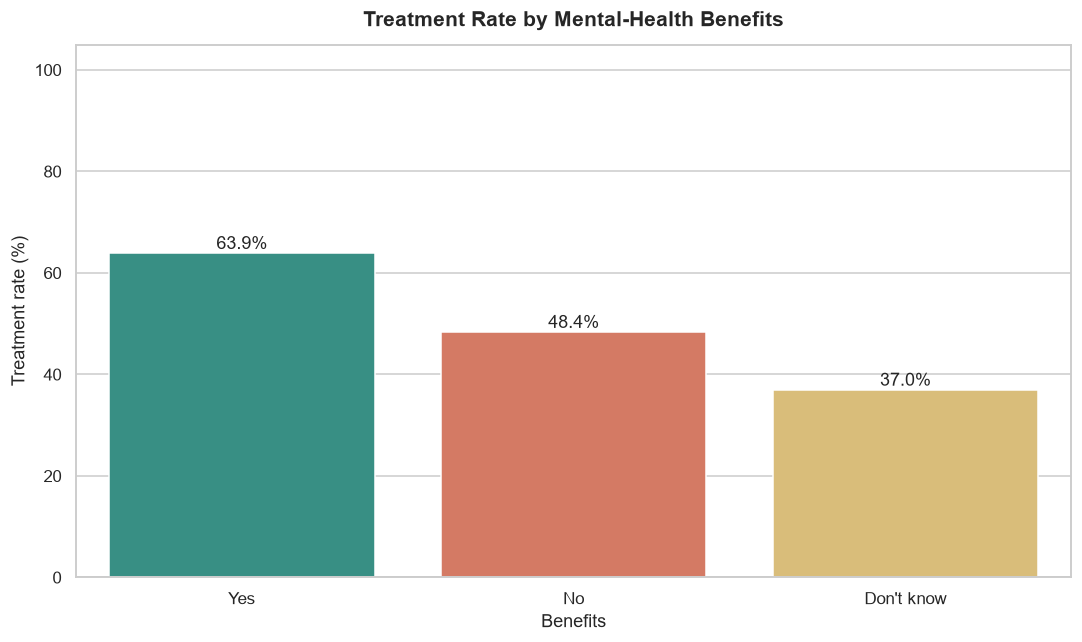

Why this graph:
A percentage bar chart was selected to compare treatment rates across benefit availability and awareness categories.

Insights: Respondents reporting available benefits have a treatment rate of 63.9%.

Positive Impact: Providing benefits and communicating them clearly may reduce financial and information barriers.

Negative Impact: Respondents who have received treatment may be more aware of benefits; therefore, the relationship does not prove causation.


In [60]:
benefit_treatment = treatment_rate_by("benefits")

ax = sns.barplot(
    data=benefit_treatment,
    x="benefits",
    y="Treatment_Rate",
    order=benefits_order,
    hue="benefits",
    palette={
        "Yes": "#2A9D8F",
        "No": "#E76F51",
        "Don't know": "#E9C46A"
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Mental-Health Benefits",
    "Benefits",
    "Treatment rate (%)"
)

benefit_rate_values = benefit_treatment.set_index(
    "benefits"
)["Treatment_Rate"]



print("Why this graph:\nA percentage bar chart was selected to compare treatment rates across benefit availability and awareness categories.")
print(f"\nInsights: Respondents reporting available benefits have a treatment rate of {benefit_rate_values['Yes']:.1f}%.")
print("\nPositive Impact: Providing benefits and communicating them clearly may reduce financial and information barriers.")
print("\nNegative Impact: Respondents who have received treatment may be more aware of benefits; therefore, the relationship does not prove causation.")

# Chart 14: Care Options and Treatment

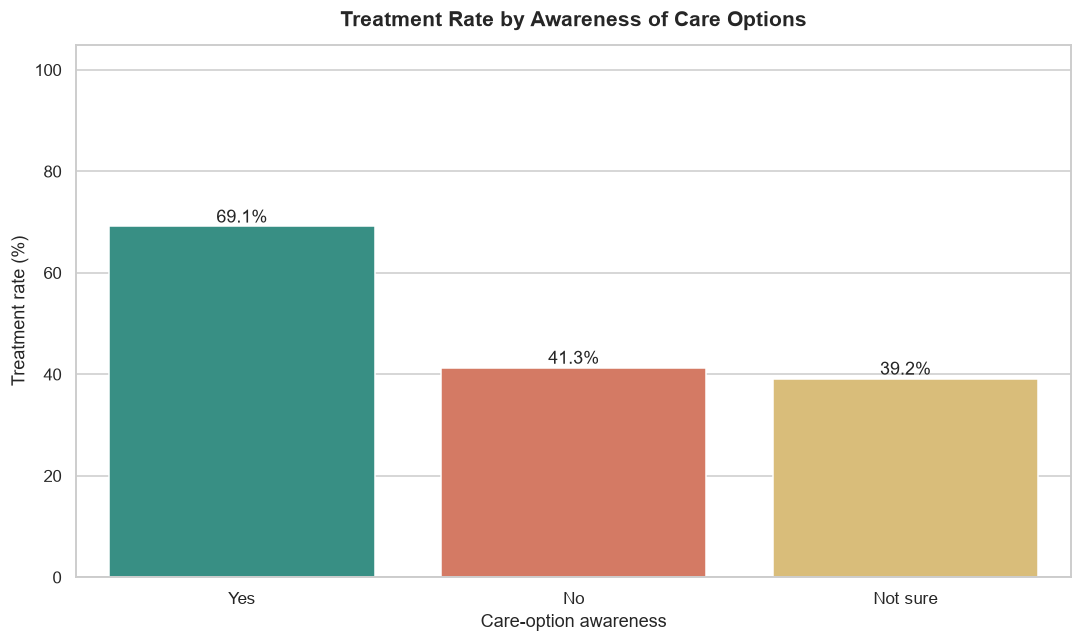

Why this graph:
A percentage bar chart was selected to compare treatment rates among employees with different levels of care-option awareness.

Insights: The treatment-rate difference between Yes and No awareness groups is 27.8 percentage points.

Positive Impact: Improving care-option awareness may make treatment pathways easier to understand.

Negative Impact: Awareness may have developed after treatment was sought, so the relationship should not be treated as causal.


In [62]:
care_treatment = treatment_rate_by("care_options")

ax = sns.barplot(
    data=care_treatment,
    x="care_options",
    y="Treatment_Rate",
    order=care_order,
    hue="care_options",
    palette={
        "Yes": "#2A9D8F",
        "No": "#E76F51",
        "Not sure": "#E9C46A"
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Awareness of Care Options",
    "Care-option awareness",
    "Treatment rate (%)"
)

care_rate_values = care_treatment.set_index(
    "care_options"
)["Treatment_Rate"]

care_treatment_gap = (
    care_rate_values["Yes"] - care_rate_values["No"]
)

print("Why this graph:\nA percentage bar chart was selected to compare treatment rates among employees with different levels of care-option awareness.")
print(f"\nInsights: The treatment-rate difference between Yes and No awareness groups is {care_treatment_gap:.1f} percentage points.")
print("\nPositive Impact: Improving care-option awareness may make treatment pathways easier to understand.")
print("\nNegative Impact: Awareness may have developed after treatment was sought, so the relationship should not be treated as causal.")

# Chart 15: Remote Work and Treatment

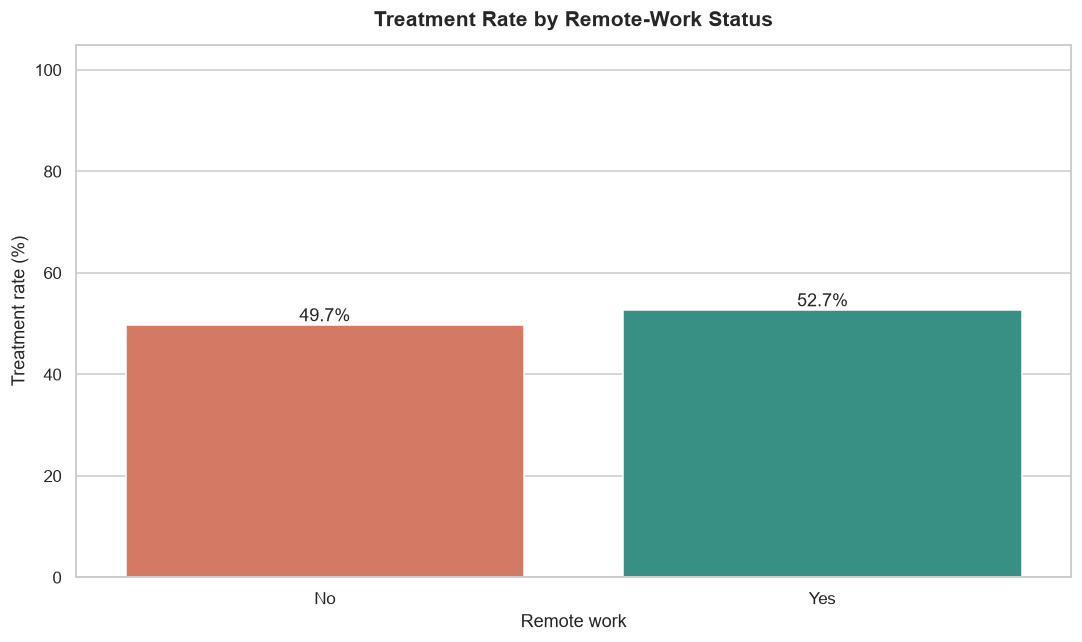

Why this graph:
A percentage bar chart was selected because remote work and treatment are both binary categorical variables.

Insights: Remote workers have a treatment-rate difference of +2.9 percentage points compared with non-remote workers.

Positive Impact: Organizations can provide both digital and in-person support based on employee work arrangements.

Negative Impact: The difference does not establish that remote work causes better or worse mental-health outcomes.


In [65]:
remote_treatment = treatment_rate_by("remote_work")

ax = sns.barplot(
    data=remote_treatment,
    x="remote_work",
    y="Treatment_Rate",
    hue="remote_work",
    palette={"Yes": "#2A9D8F", "No": "#E76F51"},
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Remote-Work Status",
    "Remote work",
    "Treatment rate (%)"
)

remote_rate_values = remote_treatment.set_index(
    "remote_work"
)["Treatment_Rate"]

remote_gap = (
    remote_rate_values["Yes"] - remote_rate_values["No"]
)


print("Why this graph:\nA percentage bar chart was selected because remote work and treatment are both binary categorical variables.")
print(f"\nInsights: Remote workers have a treatment-rate difference of {remote_gap:+.1f} percentage points compared with non-remote workers.")
print("\nPositive Impact: Organizations can provide both digital and in-person support based on employee work arrangements.")
print("\nNegative Impact: The difference does not establish that remote work causes better or worse mental-health outcomes.")

# Chart 16: Expected Consequences and Treatment

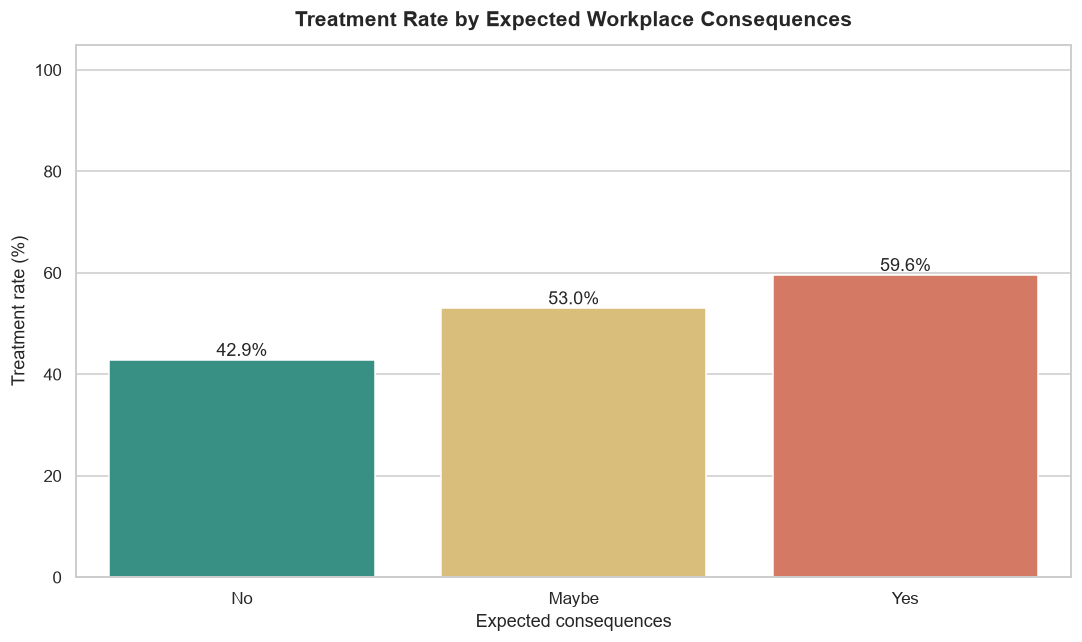

Why this graph:
An ordered percentage bar chart was selected to compare treatment rates across increasing levels of expected workplace consequences.

Insights: Respondents expecting consequences have a treatment-rate difference of +16.7 percentage points compared with those expecting no consequences.

Positive Impact: Organizations can strengthen confidentiality, psychological safety and non-retaliation policies.

Negative Impact: Fear of workplace consequences may discourage employees from seeking help or requesting support.


In [67]:
consequence_order = ["No", "Maybe", "Yes"]

consequence_treatment = treatment_rate_by(
    "mental_health_consequence"
)

ax = sns.barplot(
    data=consequence_treatment,
    x="mental_health_consequence",
    y="Treatment_Rate",
    order=consequence_order,
    hue="mental_health_consequence",
    palette={
        "No": "#2A9D8F",
        "Maybe": "#E9C46A",
        "Yes": "#E76F51"
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Expected Workplace Consequences",
    "Expected consequences",
    "Treatment rate (%)"
)

consequence_rates = consequence_treatment.set_index(
    "mental_health_consequence"
)["Treatment_Rate"]

consequence_gap = (
    consequence_rates["Yes"] - consequence_rates["No"]
)


print("Why this graph:\nAn ordered percentage bar chart was selected to compare treatment rates across increasing levels of expected workplace consequences.")
print(f"\nInsights: Respondents expecting consequences have a treatment-rate difference of {consequence_gap:+.1f} percentage points compared with those expecting no consequences.")
print("\nPositive Impact: Organizations can strengthen confidentiality, psychological safety and non-retaliation policies.")
print("\nNegative Impact: Fear of workplace consequences may discourage employees from seeking help or requesting support.")

# hart 17: Supervisor Openness and Treatment

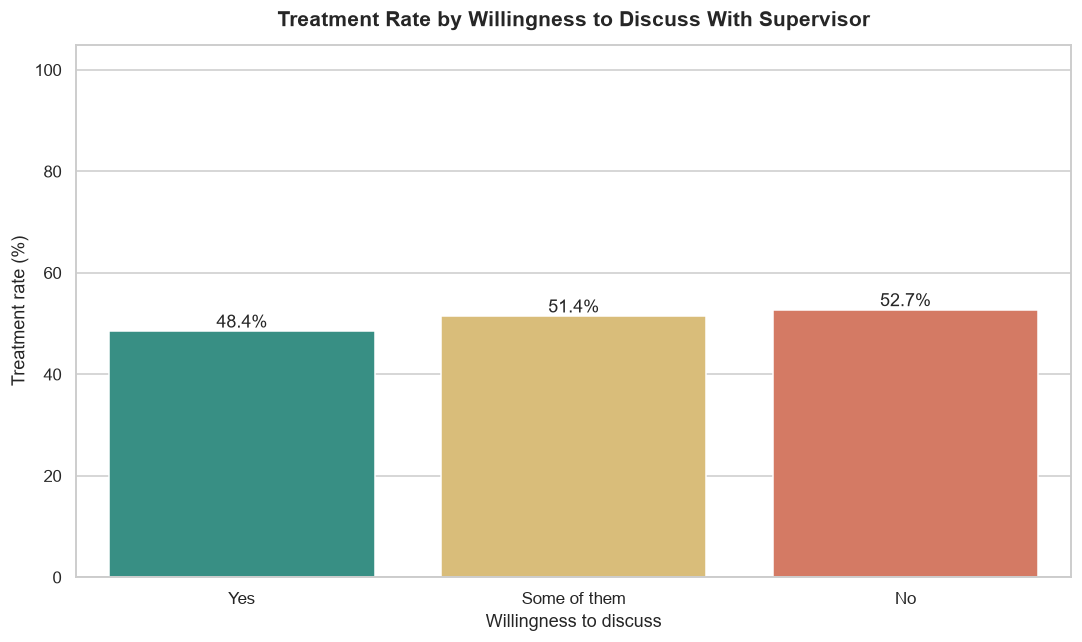

Why this graph:
A percentage bar chart was selected to compare treatment experience across different levels of willingness to speak with supervisors.

Insights: Treatment rates vary by 4.2 percentage points across supervisor-discussion categories.

Positive Impact: Supervisor training could create safer and more supportive escalation channels.

Negative Impact: Low trust in supervisors can hide problems until they affect absence, performance or retention.


In [69]:
supervisor_order = ["Yes", "Some of them", "No"]

supervisor_treatment = treatment_rate_by("supervisor")

ax = sns.barplot(
    data=supervisor_treatment,
    x="supervisor",
    y="Treatment_Rate",
    order=supervisor_order,
    hue="supervisor",
    palette={
        "Yes": "#2A9D8F",
        "Some of them": "#E9C46A",
        "No": "#E76F51"
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 105)

complete_chart(
    "Treatment Rate by Willingness to Discuss With Supervisor",
    "Willingness to discuss",
    "Treatment rate (%)"
)

supervisor_rates = supervisor_treatment.set_index(
    "supervisor"
)["Treatment_Rate"]

supervisor_spread = (
    supervisor_rates.max() - supervisor_rates.min()
)

print("Why this graph:\nA percentage bar chart was selected to compare treatment experience across different levels of willingness to speak with supervisors.")
print(f"\nInsights: Treatment rates vary by {supervisor_spread:.1f} percentage points across supervisor-discussion categories.")
print("\nPositive Impact: Supervisor training could create safer and more supportive escalation channels.")
print("\nNegative Impact: Low trust in supervisors can hide problems until they affect absence, performance or retention.")

# Chart 18: Work Interference, Family History and Treatment

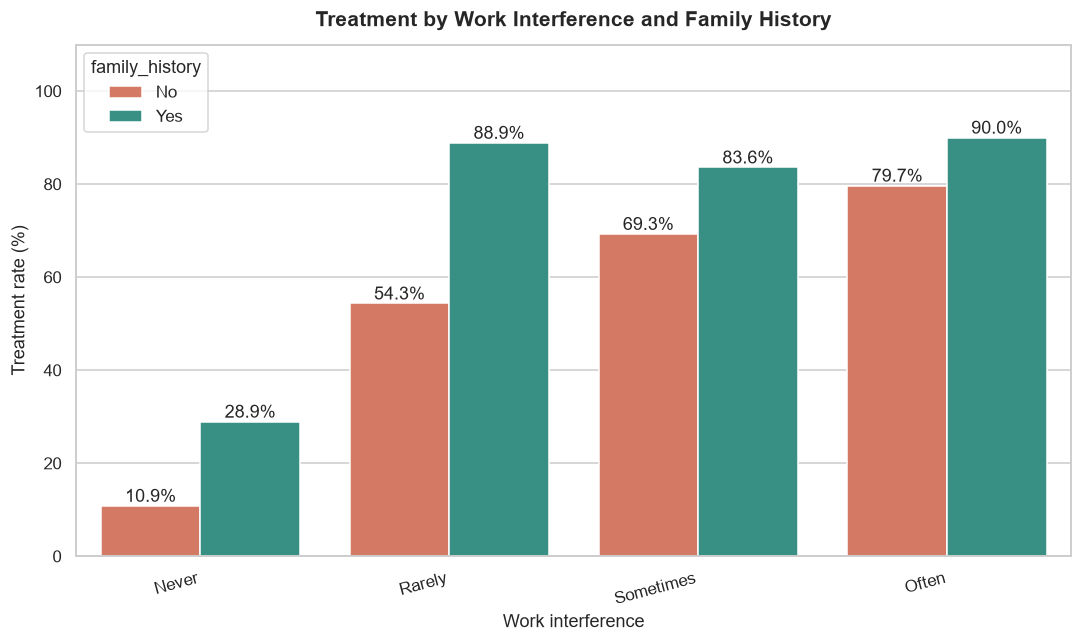

Why this graph:
A grouped bar chart was selected because it compares treatment rates using three variables: work interference, family history and treatment.

Insights: The highest observed segment reports Often interference, family history Yes, and a treatment rate of 90.0%.

Positive Impact: The analysis can identify segments that may benefit from voluntary early-support programs.

Negative Impact: Small segment sizes can produce unstable rates, and family history must always remain confidential.


In [70]:
# Exclude 'Not reported' to analyse known interference levels.
multivariate_data = df_clean[
    df_clean["work_interfere"] != "Not reported"
].copy()

multi_treatment = (
    multivariate_data
    .groupby(
        ["work_interfere", "family_history"],
        observed=True
    )["Treatment_Flag"]
    .mean()
    .mul(100)
    .reset_index(name="Treatment_Rate")
)

ax = sns.barplot(
    data=multi_treatment,
    x="work_interfere",
    y="Treatment_Rate",
    hue="family_history",
    order=["Never", "Rarely", "Sometimes", "Often"],
    hue_order=["No", "Yes"],
    palette={"Yes": "#2A9D8F", "No": "#E76F51"}
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylim(0, 110)

complete_chart(
    "Treatment by Work Interference and Family History",
    "Work interference",
    "Treatment rate (%)",
    rotation=15
)

highest_segment = multi_treatment.loc[
    multi_treatment["Treatment_Rate"].idxmax()
]


print("Why this graph:\nA grouped bar chart was selected because it compares treatment rates using three variables: work interference, family history and treatment.")
print(f"\nInsights: The highest observed segment reports {highest_segment['work_interfere']} interference, family history {highest_segment['family_history']}, and a treatment rate of {highest_segment['Treatment_Rate']:.1f}%.")
print("\nPositive Impact: The analysis can identify segments that may benefit from voluntary early-support programs.")
print("\nNegative Impact: Small segment sizes can produce unstable rates, and family history must always remain confidential.")

# Chart 19: Treatment Priority Heatmap

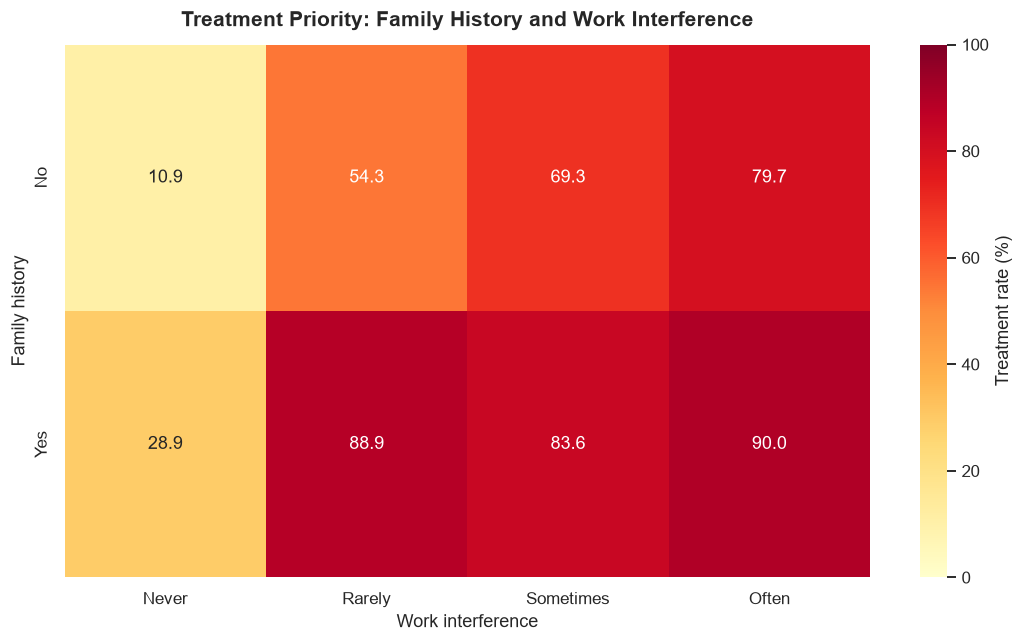

Why this graph:
A heatmap was selected because it makes high and low treatment-rate combinations easy to identify using colour intensity.

Insights: The highest cell is family history Yes and Often work interference, with a treatment rate of 90.0%.

Positive Impact: The heatmap helps decision-makers quickly identify priority groups for aggregated and voluntary support.

Negative Impact: A high treatment rate is not itself negative. The important risk signal is the underlying work interference and possible unmet need.


In [71]:
priority_table = (
    multivariate_data
    .pivot_table(
        index="family_history",
        columns="work_interfere",
        values="Treatment_Flag",
        aggfunc="mean",
        observed=True
    )
    .mul(100)
)

priority_table = priority_table.reindex(
    index=["No", "Yes"],
    columns=["Never", "Rarely", "Sometimes", "Often"]
)

sns.heatmap(
    priority_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Treatment rate (%)"}
)

complete_chart(
    "Treatment Priority: Family History and Work Interference",
    "Work interference",
    "Family history"
)

highest_cell = priority_table.stack().idxmax()
highest_value = priority_table.stack().max()



print("Why this graph:\nA heatmap was selected because it makes high and low treatment-rate combinations easy to identify using colour intensity.")
print(f"\nInsights: The highest cell is family history {highest_cell[0]} and {highest_cell[1]} work interference, with a treatment rate of {highest_value:.1f}%.")
print("\nPositive Impact: The heatmap helps decision-makers quickly identify priority groups for aggregated and voluntary support.")
print("\nNegative Impact: A high treatment rate is not itself negative. The important risk signal is the underlying work interference and possible unmet need.")

# Chart 20: Support Score by Treatment and Family History

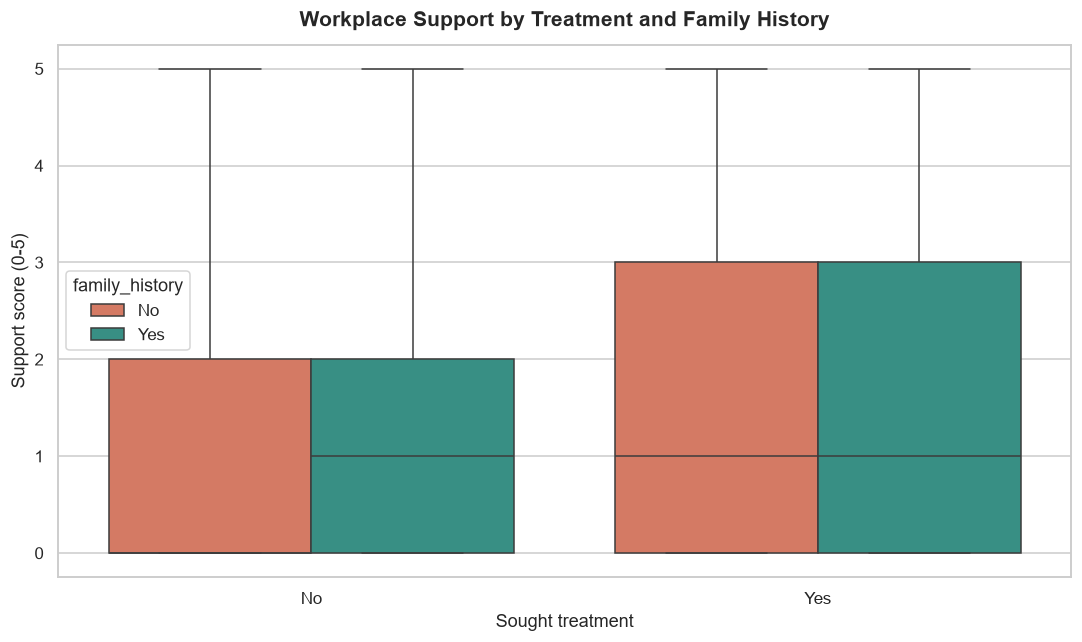

Why this graph:
A grouped box plot was selected because it compares the distribution of a numerical support score across two categorical variables.

Insights: Average support ranges from 0.98 for ('No', 'No') to 1.78 for ('Yes', 'Yes').

Positive Impact: Support-score differences can guide improvements in policies, resources and employee communication.

Negative Impact: The score is perception-based and must not be used to evaluate or diagnose individual employees.


In [73]:
ax = sns.boxplot(
    data=df_clean,
    x="treatment",
    y="Support_Score",
    hue="family_history",
    order=["No", "Yes"],
    hue_order=["No", "Yes"],
    palette={"Yes": "#2A9D8F", "No": "#E76F51"}
)

complete_chart(
    "Workplace Support by Treatment and Family History",
    "Sought treatment",
    "Support score (0-5)"
)

support_summary = (
    df_clean.groupby(
        ["treatment", "family_history"]
    )["Support_Score"]
    .mean()
)

lowest_support_segment = support_summary.idxmin()
highest_support_segment = support_summary.idxmax()

print("Why this graph:\nA grouped box plot was selected because it compares the distribution of a numerical support score across two categorical variables.")
print(f"\nInsights: Average support ranges from {support_summary.loc[lowest_support_segment]:.2f} for {lowest_support_segment} to {support_summary.loc[highest_support_segment]:.2f} for {highest_support_segment}.")
print("\nPositive Impact: Support-score differences can guide improvements in policies, resources and employee communication.")
print("\nNegative Impact: The score is perception-based and must not be used to evaluate or diagnose individual employees.")


#### Suggestions to Achieve the Business Objective

The main business objective should be to create a supportive workplace that improves access to mental-health resources, reduces stigma, and minimizes the effect of mental-health conditions on employee productivity, absenteeism and retention.

Based on the analysis, the following actions are recommended:

1. **Improve awareness of mental-health benefits**
   - Publish a simple guide explaining available benefits, eligibility, cost and the process for accessing care.
   - Communicate the information through onboarding, email, the employee portal and periodic awareness sessions.
   - This is important because many respondents do not know whether mental-health benefits are available.

2. **Make care options easier to access**
   - Create a centralized and confidential mental-health support portal.
   - Provide information about counselling, Employee Assistance Programs, insurance coverage, helplines and external specialists.
   - Easy access can encourage employees to seek help before their condition begins to interfere severely with work.

3. **Clarify the mental-health leave policy**
   - Clearly explain eligibility, approval procedures, required documentation and confidentiality rules.
   - Train managers and HR teams to apply the leave policy consistently.
   - This can reduce uncertainty, presenteeism and delayed treatment.

4. **Train supervisors and managers**
   - Conduct training on recognizing warning signs, responding empathetically, maintaining confidentiality and referring employees to professional support.
   - Managers should support employees without attempting to diagnose them.
   - This can improve psychological safety and employee trust.

5. **Reduce stigma and fear of negative consequences**
   - Establish clear non-retaliation and confidentiality policies.
   - Conduct mental-health awareness programs and leadership-supported campaigns.
   - Employees should feel safe seeking support without fearing damage to their careers.

6. **Provide early intervention for work interference**
   - Offer confidential counselling, flexible schedules, workload adjustments and reasonable accommodations.
   - Give priority to aggregated groups reporting that mental health interferes with work sometimes or often.
   - Early support may prevent productivity loss, absenteeism, burnout and attrition.

7. **Offer support for remote and office-based employees**
   - Provide virtual counselling and digital resources for remote employees.
   - Maintain in-person support and private consultation channels for office-based employees.
   - Mental-health support should be equally accessible regardless of work location.

8. **Maintain employee privacy**
   - Use survey findings only in aggregated form.
   - Do not use treatment history, gender or family history for recruitment, promotion, performance evaluation or individual risk scoring.
   - Apply a minimum group-size rule before reporting segmented results.

9. **Conduct regular anonymous pulse surveys**
   - Repeat selected questions quarterly or half-yearly.
   - Monitor changes in awareness, psychological safety, work interference and support satisfaction.
   - This will allow the organization to determine whether its interventions are working.

10. **Track measurable KPIs**
    - Percentage of employees aware of available benefits
    - Percentage aware of care options
    - Employee Assistance Program utilization rate
    - Percentage finding mental-health leave easy to understand
    - Percentage feeling safe discussing mental health
    - Frequency of mental-health-related work interference
    - Absenteeism, engagement and voluntary attrition trends

#### Expected Business Outcome

These recommendations can improve employee wellbeing, trust and engagement while reducing avoidable absence, presenteeism, productivity loss and employee turnover. Because the survey is observational and self-reported, the organization should test the recommendations through pilot programs and compare KPIs before and after implementation.

# Conclusion

The analysis shows that workplace mental health significantly affects employees’ wellbeing and work performance. Major concerns include limited awareness of benefits and care options, uncertainty about mental-health leave, and fear of workplace consequences. Organizations should improve communication, provide confidential support, train managers, and promote a stigma-free culture to enhance employee wellbeing, productivity, and retention.